# Universal Oblivious Amplitude Amplification (OAA)

Oblivious Amplitude Amplification (OAA) is a powerful quantum algorithmic subroutine, famously used in contexts like Linear Combination of Unitaries (LCU) for Hamiltonian simulation. Unlike standard Grover's algorithm, OAA amplifies the success probability of a non-unitary operation applied to a data register *without* requiring any knowledge of the data register's state, and crucially, without destroying the quantum information encoded within it.

### The Computational Basis and Geometry
In this notebook, we map the quantum states to a 2D geometric plane corresponding to the computational basis of the ancilla qubit:
*   **X-Axis (Success):** The ancilla is measured as $|0\rangle \equiv \begin{pmatrix} 1 \\ 0 \end{pmatrix}$. This indicates that the target operation was successfully applied to the data.
*   **Y-Axis (Failure):** The ancilla is measured as $|1\rangle \equiv \begin{pmatrix} 0 \\ 1 \end{pmatrix}$. This indicates that an unwanted operator was applied, and the operation failed.

The algorithm geometrically rotates the state vector from the Y-axis (high probability of failure) toward the X-axis (100% success).

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

## 1. Mathematical Framework and Optimal Iterations

Let $P$ be the initial target probability of success (e.g., $0.05$ for $5\%$). We define the state vector's initial angle $\theta$ relative to the Y-axis (Failure) such that the probability of measuring the success state ($|0\rangle$) is:
$$ P = \sin^2(\theta) \implies \theta = \arcsin(\sqrt{P}) $$

Each iteration of the OAA operator $Q$ rotates the state vector by an angle of $2\theta$. After $k$ iterations, the total angle $\theta_k$ relative to the failure axis is:
$$ \theta_k = (2k + 1)\theta $$

Our goal is to align the vector as perfectly as possible with the X-axis (Success), which corresponds to an angle of $\frac{\pi}{2}$ ($90^\circ$). We solve for the optimal number of iterations $k$:
$$ (2k + 1)\theta \approx \frac{\pi}{2} \implies k \approx \frac{\pi}{4\theta} - \frac{1}{2} $$
Since $k$ must be an integer, we round this value to the nearest whole number. 

*Note: You can change `target_prob` below, and the notebook will dynamically calculate everything.*

In [10]:
# --- SETTING INITIAL PROBABILITY --- 
target_prob = 0.05  # Try changing this to 0.02, 0.10, or 0.25

# Calculate the base angle theta in radians and degrees
theta_rad = np.arcsin(np.sqrt(target_prob))
theta_deg = np.degrees(theta_rad)

# Calculate optimal iterations (k)
optimal_k = int(round((np.pi / (4 * theta_rad)) - 0.5))
max_k = optimal_k + 1 # Add one extra iteration to demonstrate the overshoot effect

print(f"Target Initial Probability: {target_prob * 100:.2f}%")
print(f"Initial Angle (theta): {theta_deg:.2f}°")
print(f"Calculated Optimal Iterations (k): {optimal_k}")

Target Initial Probability: 5.00%
Initial Angle (theta): 12.92°
Calculated Optimal Iterations (k): 3


## 2. Defining the Quantum Operators

We define three main components for the OAA routine:

1.  **Preparation Operator ($W$):** In an LCU framework, this operator prepares the superposition of states and applies controlled unitaries to the data. To match our geometric mapping (where we start close to the Y-axis, $|1\rangle$), we initialize the ancilla in $|1\rangle$ using an $X$ gate, and then apply an $R_y(2\theta)$ rotation to "spill" a predefined fraction of the probability into the success state $|0\rangle$.
2.  **Inverse Operator ($W^\dagger$):** The exact hermitian conjugate of $W$.
3.  **The OAA Iterator ($Q$):** Defined as $Q = -W Z_0 W^\dagger Z_0$. The $Z_0$ gates act **exclusively on the ancilla qubit**, flipping the phase of the $|0\rangle$ state. This localized reflection is the core mechanism that makes the amplification "oblivious" to the passenger data register.

In [11]:
# --- 2. OPERATOR DEFINITIONS ---

def W():
    qc = QuantumCircuit(2, name=" W ")
    qc.x(0) # Start in the failure state |1> (Y-axis)
    qc.ry(2 * theta_rad, 0) # Rotate a small probability into the success state |0> (X-axis)
    qc.cx(0, 1) # Entangle with data (data acts as a passive passenger)
    return qc.to_instruction()

def W_dg():
    qc = QuantumCircuit(2, name=" W^dagger ")
    qc.cx(0, 1)
    qc.ry(-2 * theta_rad, 0)
    qc.x(0)
    return qc.to_instruction()

def Q():
    qc = QuantumCircuit(2, name=" Q ")
    qc.z(0)                  
    qc.append(W_dg(), [0, 1])
    qc.z(0)                  
    qc.append(W(), [0, 1])
    return qc.to_instruction()

## 3. Simulation, Exact Math, and Visualization

We will now execute the circuit iteratively from $k=0$ up to $k = k_{\text{optimal}} + 1$. The final iteration explicitly demonstrates the **overshoot phenomenon** (the "soufflé problem"), where applying too many quantum rotations causes the state vector to cross the X-axis and drop into negative amplitudes, drastically reducing the probability of success.

For each iteration, we output:
*   **The exact Statevector:** To observe the pure, noiseless mathematical amplitudes ($P_{exact} = \sin^2(\theta_k)$).
*   **The AerSimulator (2048 shots):** To observe how classical measurement frequencies converge to the theoretical probabilities.


ITERATION k = 0
Theoretical Angle:        12.92°
Mathematical Probability: 5.00 % (Success)
Measured Probability:     4.93 % (from 2048 shots)
----------------------------------------------------------------------


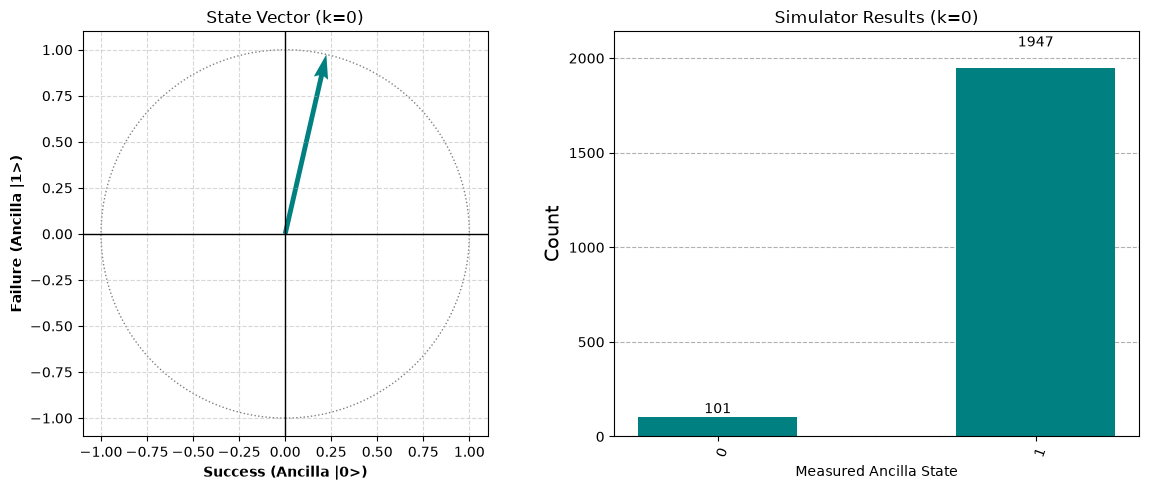


ITERATION k = 1
Theoretical Angle:        38.76°
Mathematical Probability: 39.20 % (Success)
Measured Probability:     39.75 % (from 2048 shots)
----------------------------------------------------------------------


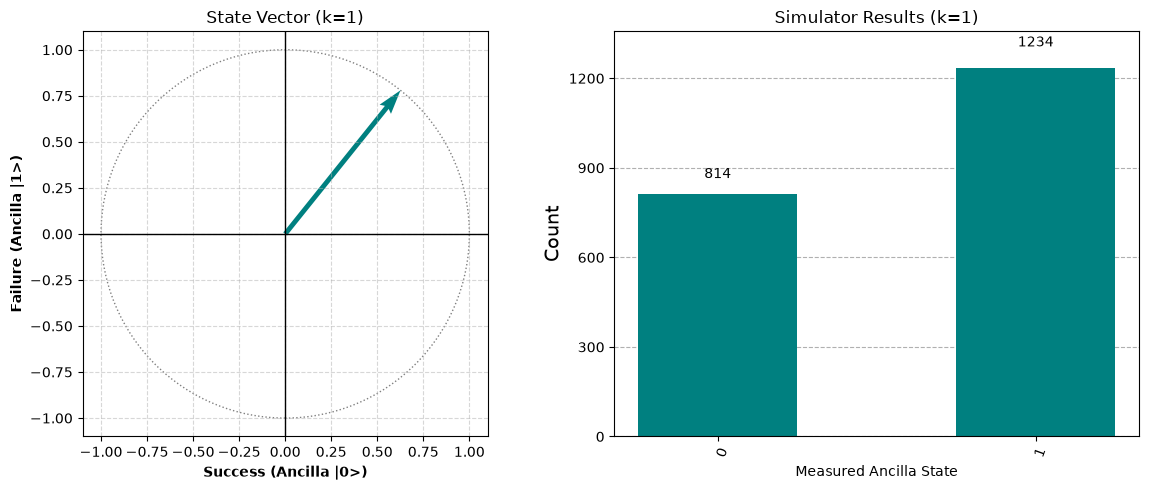


ITERATION k = 2
Theoretical Angle:        64.60°
Mathematical Probability: 81.61 % (Success)
Measured Probability:     81.15 % (from 2048 shots)
----------------------------------------------------------------------


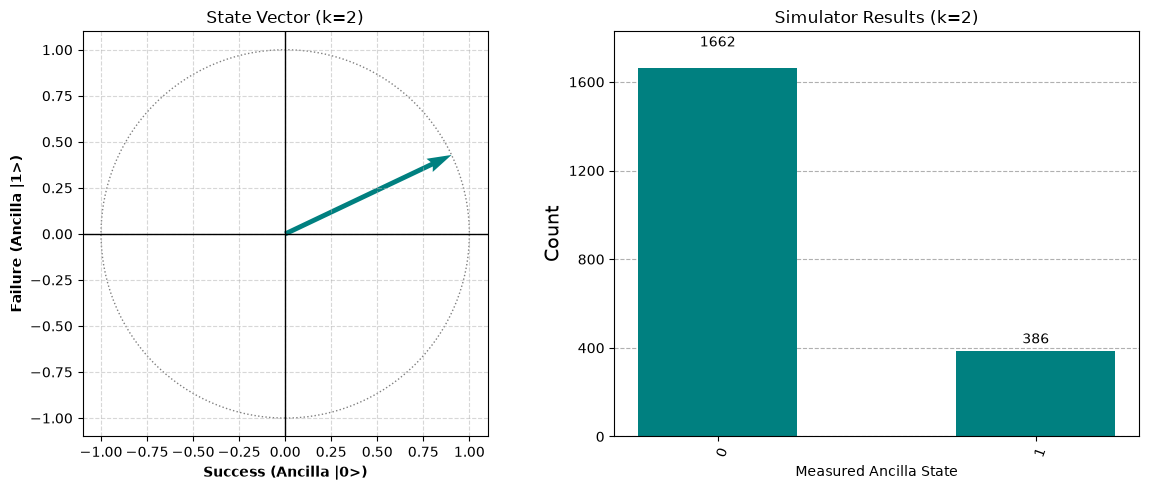


ITERATION k = 3
Theoretical Angle:        90.45°
Mathematical Probability: 99.99 % (Success)
Measured Probability:     99.95 % (from 2048 shots)
----------------------------------------------------------------------


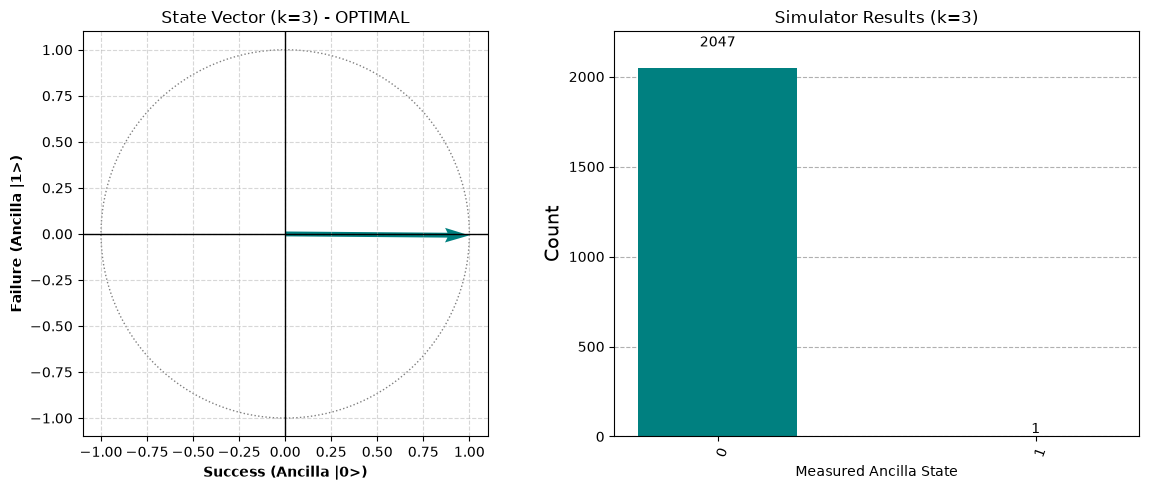


ITERATION k = 4
Theoretical Angle:        116.29°
Mathematical Probability: 80.38 % (Success)
Measured Probability:     81.30 % (from 2048 shots)
----------------------------------------------------------------------


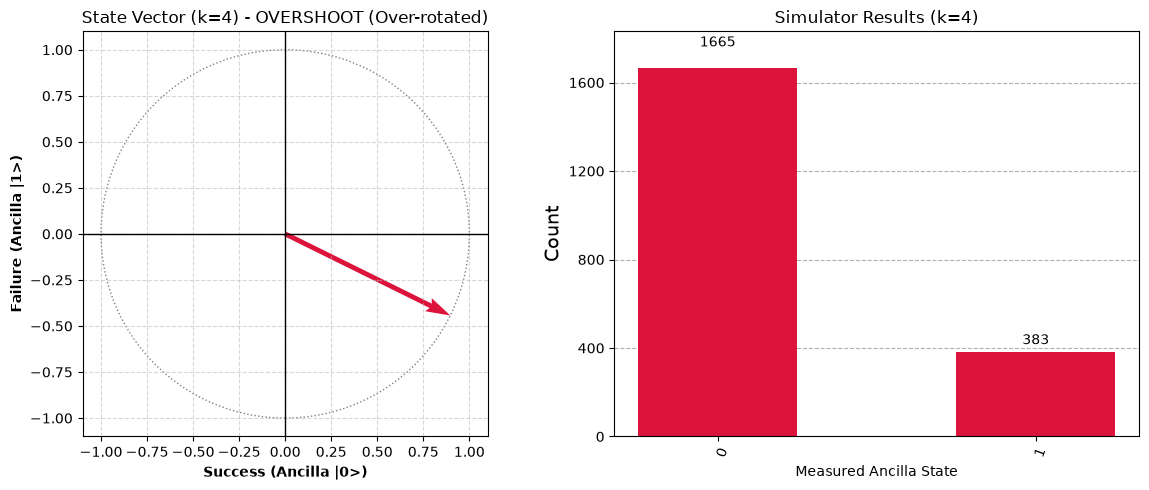

In [12]:
simulator = AerSimulator()
shots = 2048

for k in range(max_k + 1):
    # --- A. BUILD CIRCUIT ---
    qc_base = QuantumCircuit(2)
    qc_base.append(W(), [0, 1])
    for _ in range(k):
        qc_base.append(Q(), [0, 1])
        
    # --- B. EXACT MATH (Statevector) ---
    sv = Statevector(qc_base)
    probs = sv.probabilities([0]) # Marginalize over the data qubit to isolate the ancilla
    prob_good_exact = probs[0]    # Probability of state |0>
    prob_bad_exact = probs[1]     # Probability of state |1>
    theoretical_angle = (2 * k + 1) * theta_deg

    # --- C. MEASUREMENT (Simulator) ---
    qc_meas = QuantumCircuit(2, 1)
    qc_meas.append(qc_base, [0, 1])
    qc_meas.measure(0, 0)
    
    transpiled_qc = transpile(qc_meas, simulator)
    counts = simulator.run(transpiled_qc, shots=shots).result().get_counts()
    measured_good_prob = counts.get('0', 0) / shots
    
    # --- D. PRINT STATISTICS ---
    print("\n" + "="*70)
    print(f"ITERATION k = {k}")
    print("="*70)
    print(f"Theoretical Angle:        {theoretical_angle:.2f}°")
    print(f"Mathematical Probability: {prob_good_exact * 100:.2f} % (Success)")
    print(f"Measured Probability:     {measured_good_prob * 100:.2f} % (from {shots} shots)")
    print("-"*70)

    # --- E. VISUALIZATION ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # 2D Vector - Fixed 1:1 aspect ratio with space to observe overshoot into negative space
    ax1.set_xlim(-1.1, 1.1)
    ax1.set_ylim(-1.1, 1.1)
    ax1.set_aspect('equal', adjustable='box') 
    
    ax1.axhline(0, color='black', linewidth=1)
    ax1.axvline(0, color='black', linewidth=1)
    ax1.grid(True, linestyle='--', alpha=0.5)
    circle = plt.Circle((0, 0), 1.0, color='gray', fill=False, linestyle=':')
    ax1.add_patch(circle)
    
    # X = |0> (Success, mapped to Sine)
    # Y = |1> (Failure, mapped to Cosine)
    x_coord = np.sin(np.radians(theoretical_angle))
    y_coord = np.cos(np.radians(theoretical_angle))
    
    ax1.quiver(0, 0, x_coord, y_coord, angles='xy', scale_units='xy', scale=1, 
               color='teal' if k < max_k else 'crimson', width=0.012)
    
    ax1.set_xlabel("Success (Ancilla |0>)", fontweight='bold')
    ax1.set_ylabel("Failure (Ancilla |1>)", fontweight='bold')
    
    title_vec = f"State Vector (k={k})"
    if k == optimal_k:
        title_vec += " - OPTIMAL"
    elif k == max_k:
        title_vec += " - OVERSHOOT (Over-rotated)"
    ax1.set_title(title_vec)
    
    # Histogram for simulator results
    plot_histogram(counts, ax=ax2, color='teal' if k < max_k else 'crimson', title=f"Simulator Results (k={k})")
    ax2.set_xlabel("Measured Ancilla State")
    
    plt.tight_layout()
    display(fig)
    plt.close(fig)
